In [51]:
import pandas as pd
import numpy as np
import seaborn as sns
import sqlite3
import json
import requests
import matplotlib.pyplot as plt


In [32]:
csv_data = pd.read_csv("customers.csv")


In [34]:
csv_data.head()

,CustomerID,Age,Gender,Income,Purchases,MembershipYears,LastPurchaseDays,Category,Churn
0,1,56,Male,65648,15,6,277,Furniture,0
1,2,69,Male,29516,19,9,64,Clothing,0
2,3,46,Male,22396,7,8,346,Furniture,1
3,4,32,Female,104082,28,3,292,Clothing,0
4,5,60,Male,39129,43,5,245,Clothing,0


In [ ]:
csv_data.shape

(1000, 9)

In [ ]:
csv_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Gender            1000 non-null   str  
 3   Income            1000 non-null   int64
 4   Purchases         1000 non-null   int64
 5   MembershipYears   1000 non-null   int64
 6   LastPurchaseDays  1000 non-null   int64
 7   Category          1000 non-null   str  
 8   Churn             1000 non-null   int64
dtypes: int64(7), str(2)
memory usage: 70.4 KB


In [35]:
csv_data.describe()

,CustomerID,Age,Income,Purchases,MembershipYears,LastPurchaseDays,Churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,70336.159000,25.769000,4.986000,187.545000,0.088000
std,288.819436,14.99103,28781.841939,14.205542,2.620433,102.430962,0.283437
min,1.000000,18.00000,20163.000000,1.000000,1.000000,1.000000,0.000000
25%,250.750000,31.00000,46361.750000,14.000000,3.000000,101.000000,0.000000
50%,500.500000,44.00000,69191.500000,26.000000,5.000000,190.000000,0.000000
75%,750.250000,56.00000,94708.000000,38.000000,7.000000,275.250000,0.000000
max,1000.000000,69.00000,119986.000000,49.000000,9.000000,364.000000,1.000000


In [36]:
csv_data.isnull().sum()
csv_data.duplicated().sum()

np.int64(0)

In [23]:
json_data=pd.read_json("customers.json")

In [24]:
json_data.head()

,CustomerID,Age,Gender,Income,Purchases,MembershipYears,LastPurchaseDays,Category,Churn
0,1,56,Male,65648,15,6,277,Furniture,0
1,2,69,Male,29516,19,9,64,Clothing,0
2,3,46,Male,22396,7,8,346,Furniture,1
3,4,32,Female,104082,28,3,292,Clothing,0
4,5,60,Male,39129,43,5,245,Clothing,0


In [26]:
conn = sqlite3.connect("customers.db")
sql_data = pd.read_sql(
    "SELECT * FROM customers",
    conn
)

sql_data.head()

,CustomerID,Age,Gender,Income,Purchases,MembershipYears,LastPurchaseDays,Category,Churn
0,1,56,Male,65648,15,6,277,Furniture,0
1,2,69,Male,29516,19,9,64,Clothing,0
2,3,46,Male,22396,7,8,346,Furniture,1
3,4,32,Female,104082,28,3,292,Clothing,0
4,5,60,Male,39129,43,5,245,Clothing,0


In [29]:
url = "https://randomuser.me/api/?results=5"

response = requests.get(url)

print(response.status_code) 

data = response.json()

print(data)

200
{'results': [{'gender': 'male', 'name': {'title': 'Mr', 'first': 'Fausto', 'last': 'Rezende'}, 'location': {'street': {'number': 6206, 'name': 'Rua Um'}, 'city': 'Caucaia', 'state': 'Goiás', 'country': 'Brazil', 'postcode': 91929, 'coordinates': {'latitude': '-77.1806', 'longitude': '-103.4775'}, 'timezone': {'offset': '+4:00', 'description': 'Abu Dhabi, Muscat, Baku, Tbilisi'}}, 'email': 'fausto.rezende@example.com', 'login': {'uuid': '6da9e34e-b9c7-4010-8909-91d1fe045f9f', 'username': 'beautifulmouse649', 'password': 'mouse', 'salt': 'TMUEaebd', 'md5': 'f48d01c2099e350752474aa70ed19cb3', 'sha1': 'cfbe91a5ee488ba92b9d8b95ab6a1309f276174c', 'sha256': '6aecd9851a369345100d35e81f4f8c72ede9d20ebf0d71bdb8342f268984dceb'}, 'dob': {'date': '1950-02-28T00:45:33.680Z', 'age': 76}, 'registered': {'date': '2019-01-03T20:48:33.404Z', 'age': 7}, 'phone': '(98) 0239-5902', 'cell': '(21) 3597-6192', 'id': {'name': 'CPF', 'value': '936.049.741-60'}, 'picture': {'large': 'https://randomuser.me/api

In [37]:
combined_data = pd.concat(
    [csv_data, json_data],
    ignore_index=True,
    sort=False
)

combined_data.head()

,CustomerID,Age,Gender,Income,Purchases,MembershipYears,LastPurchaseDays,Category,Churn
0,1,56,Male,65648,15,6,277,Furniture,0
1,2,69,Male,29516,19,9,64,Clothing,0
2,3,46,Male,22396,7,8,346,Furniture,1
3,4,32,Female,104082,28,3,292,Clothing,0
4,5,60,Male,39129,43,5,245,Clothing,0


In [38]:
df = combined_data.copy()

df.head()

,CustomerID,Age,Gender,Income,Purchases,MembershipYears,LastPurchaseDays,Category,Churn
0,1,56,Male,65648,15,6,277,Furniture,0
1,2,69,Male,29516,19,9,64,Clothing,0
2,3,46,Male,22396,7,8,346,Furniture,1
3,4,32,Female,104082,28,3,292,Clothing,0
4,5,60,Male,39129,43,5,245,Clothing,0


In [39]:
df.describe()

,CustomerID,Age,Income,Purchases,MembershipYears,LastPurchaseDays,Churn
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,500.500000,43.81900,70336.159000,25.769000,4.986000,187.545000,0.088000
std,288.747186,14.98728,28774.641978,14.201989,2.619778,102.405339,0.283366
min,1.000000,18.00000,20163.000000,1.000000,1.000000,1.000000,0.000000
25%,250.750000,31.00000,46361.750000,14.000000,3.000000,101.000000,0.000000
50%,500.500000,44.00000,69191.500000,26.000000,5.000000,190.000000,0.000000
75%,750.250000,56.00000,94708.000000,38.000000,7.000000,275.250000,0.000000
max,1000.000000,69.00000,119986.000000,49.000000,9.000000,364.000000,1.000000


In [40]:
df.isnull().sum()

CustomerID          0
Age                 0
Gender              0
Income              0
Purchases           0
MembershipYears     0
LastPurchaseDays    0
Category            0
Churn               0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

In [43]:
df.drop_duplicates(inplace=True)

In [46]:
df.dtypes

CustomerID          int64
Age                 int64
Gender                str
Income              int64
Purchases           int64
MembershipYears     int64
LastPurchaseDays    int64
Category              str
Churn               int64
dtype: object

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Gender            1000 non-null   str  
 3   Income            1000 non-null   int64
 4   Purchases         1000 non-null   int64
 5   MembershipYears   1000 non-null   int64
 6   LastPurchaseDays  1000 non-null   int64
 7   Category          1000 non-null   str  
 8   Churn             1000 non-null   int64
dtypes: int64(7), str(2)
memory usage: 70.4 KB


In [49]:
df.head()

,CustomerID,Age,Gender,Income,Purchases,MembershipYears,LastPurchaseDays,Category,Churn
0,1,56,Male,65648,15,6,277,Furniture,0
1,2,69,Male,29516,19,9,64,Clothing,0
2,3,46,Male,22396,7,8,346,Furniture,1
3,4,32,Female,104082,28,3,292,Clothing,0
4,5,60,Male,39129,43,5,245,Clothing,0


***Univariate Analysis***


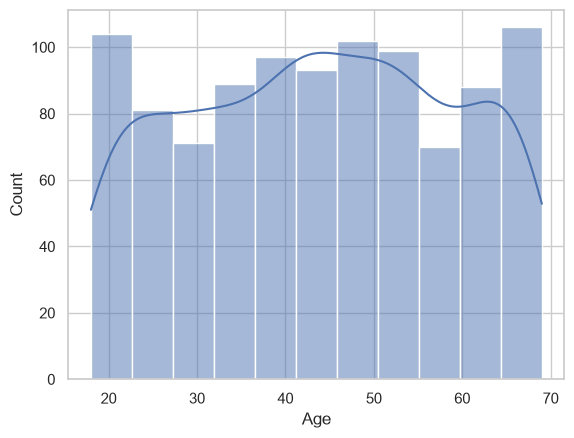

In [54]:
sns.set_theme(style="whitegrid")
sns.histplot(data=df,x="Age",kde=True)
plt.show()

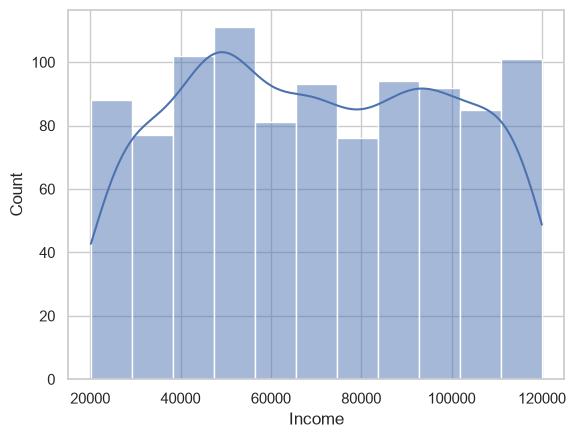

In [56]:
sns.histplot(data=df,x="Income",kde=True)
plt.show()

<Axes: xlabel='Purchases', ylabel='Count'>

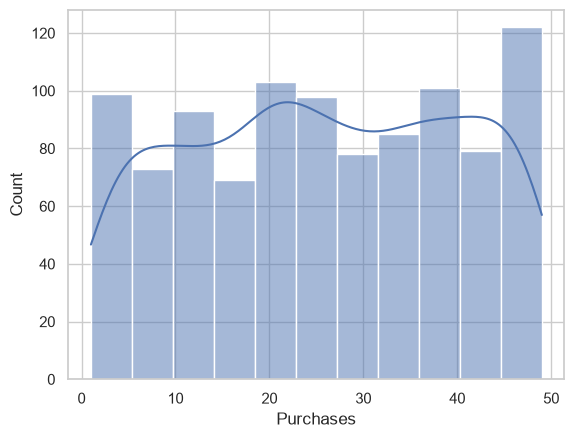

In [57]:
sns.histplot(data=df,x="Purchases",kde=True)

**Bivariate Analysis**

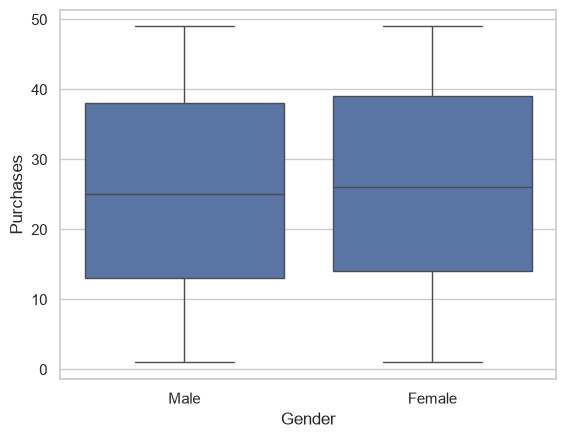

In [58]:
#gender vs purchases
sns.boxplot(data=df,x="Gender",y="Purchases")
plt.show()

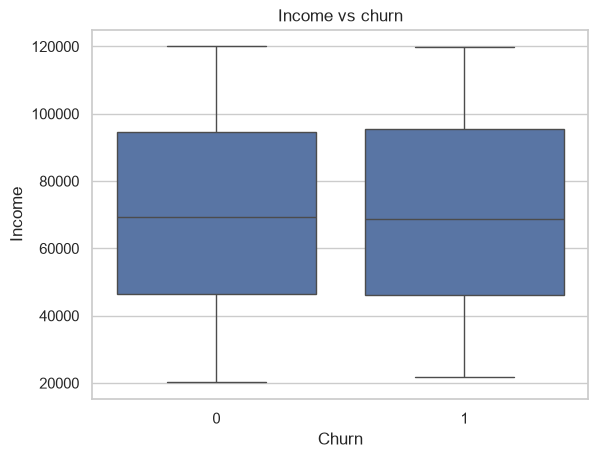

In [66]:

sns.boxplot(data=df, x="Churn", y="Income")
plt.title("Income vs churn")
plt.show()

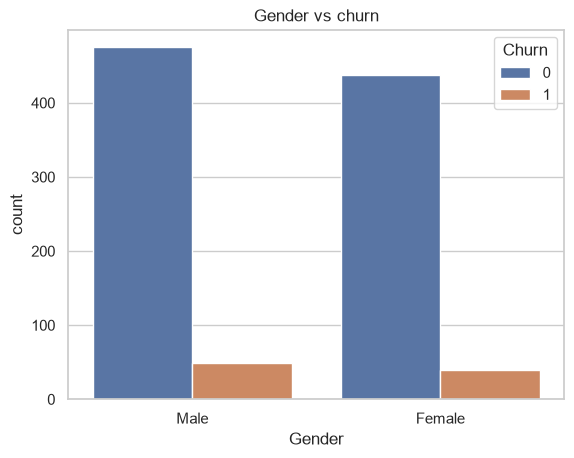

In [63]:
sns.countplot(data=df, x="Gender", hue="Churn")
plt.title("Gender vs churn")
plt.show()

***Multivariate Analysis***

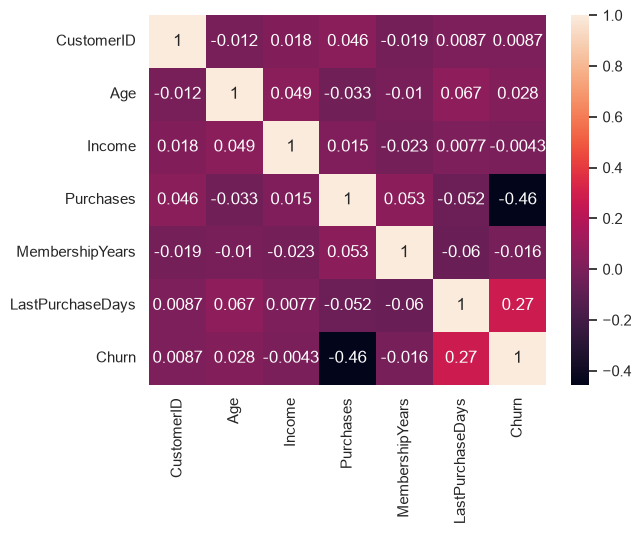

In [67]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

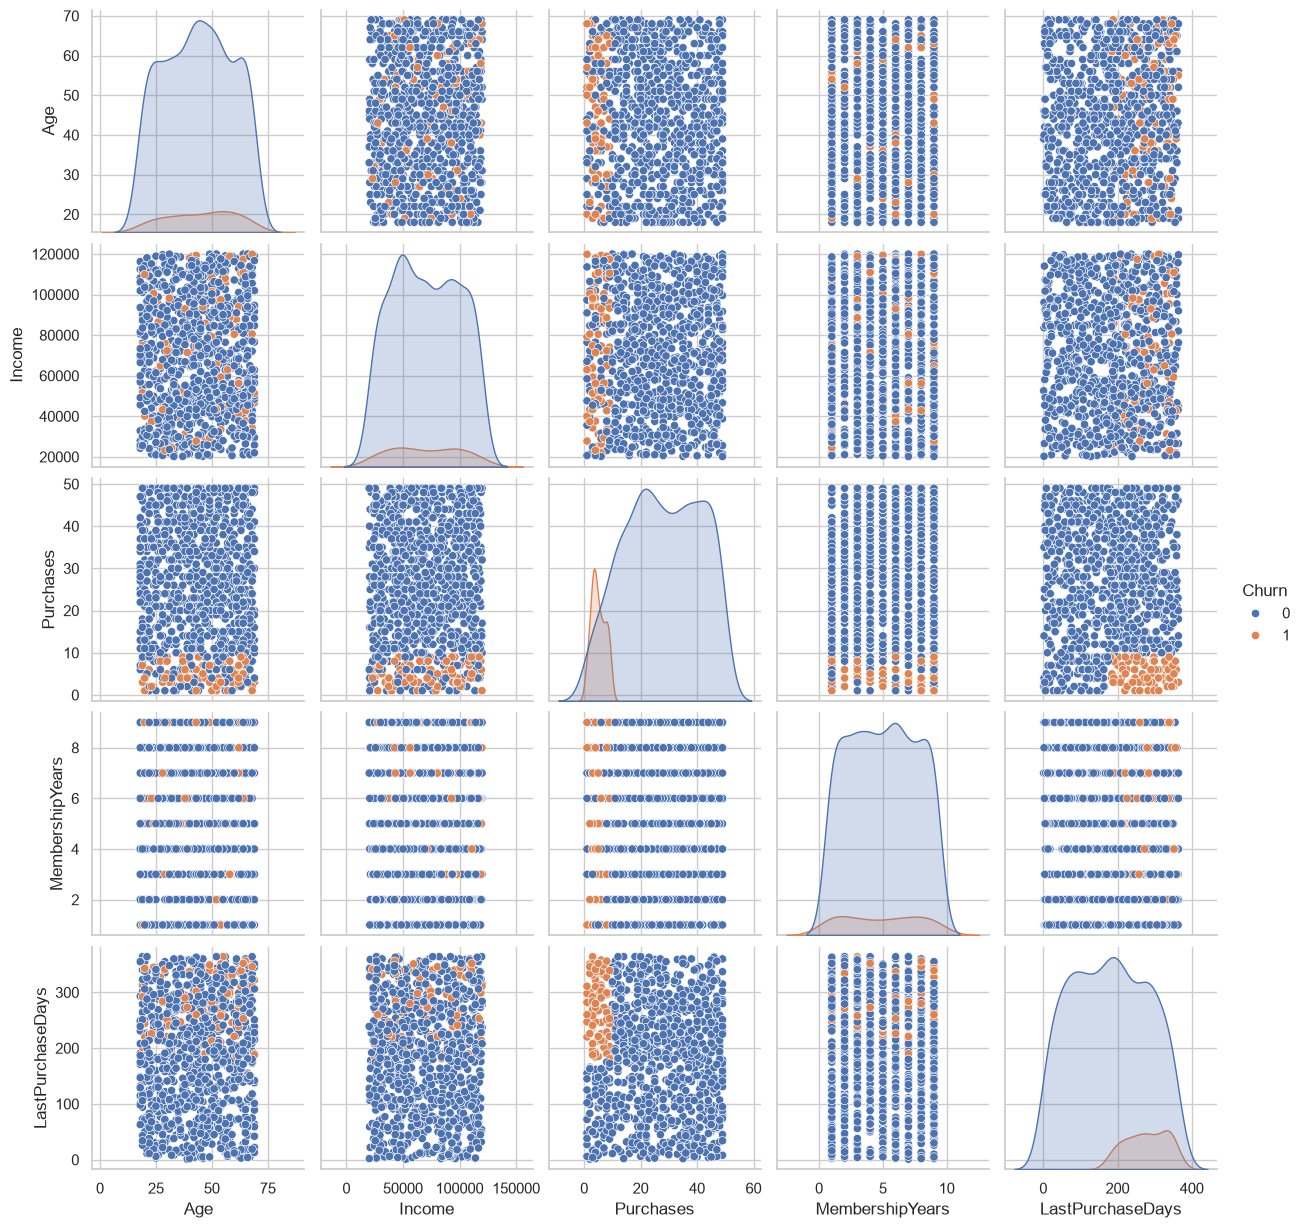

In [68]:
sns.pairplot(
    df,
    vars=[
        "Age",
        "Income",
        "Purchases",
        "MembershipYears",
        "LastPurchaseDays"
    ],
    hue="Churn"
)

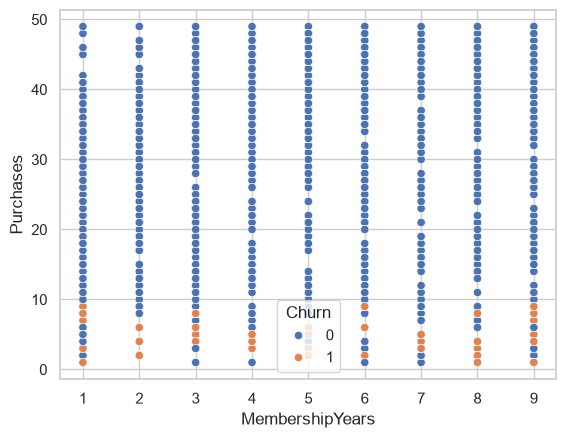

In [69]:
sns.scatterplot(
    data=df,
    x="MembershipYears",
    y="Purchases",
    hue="Churn"
)
plt.show()

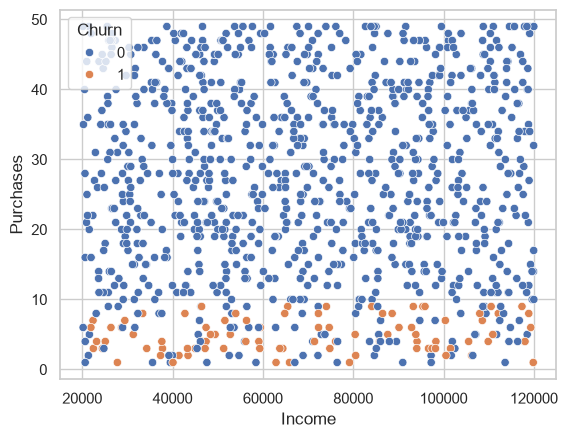

In [70]:
sns.scatterplot(
    data=df,
    x="Income",
    y="Purchases",
    hue="Churn"
)
plt.show()

In [9]:
import pandas as pd 
from ydata_profiling import ProfileReport

ModuleNotFoundError: No module named 'pkg_resources'

KeyboardInterrupt: 

In [ ]:
profile = ProfileReport( df, title="Customer Churn Dataset Profiling Report", explorative=True )